# Description
#### Test of the cell creation based on OSM data. The goal of this excercise is to give engineering a sample of cells to test the query times from the DB.

# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

#### These are libraries that I have created to query from the DB faster, they should be replaced by query_mssql as explained after on the code


In [2]:
from locallib.picarrodb import *
from locallib.query import *

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


In [3]:
#Py file where the NOP class is defined
from NOP import *

import matplotlib.pyplot as plt
from shapely import wkt


/home/sandbox/personal-repos/NumberOfPasses/NOP.py:17: UserWarning: registration of accessor <class 'NOP.NOPAccessor'> under name 'nop' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("nop")


# Query the Breadcrumbs and the survey area
Segments: For the current notebook, the breadcrumbs are only used for visualization purposes. 

For this excercise, the SurveyArea is going to be the total area covered by the surveys in the report. (Check the first lines of the next cell). The SurveyArea is needed to extract the OSM roads. In the future, they should be replaced by the Pre-driving assesment.

The segments were obtained using the some local libraries I use for faster extraction. They need to be changed into query_mssql. The query I useed to obtained the segments dataframe is the following

## get_reports
```sql
SELECT 
        C.Name AS CustomerName,
        CASE
            WHEN ReportType.Description = 'Compliance' THEN CONCAT('CR-', SUBSTRING(CONVERT(nvarchar(50), R.Id), 1, 6))
            WHEN ReportType.Description = 'Emissions' THEN CONCAT('ER-', SUBSTRING(CONVERT(nvarchar(50), R.Id), 1, 6))
            ELSE CONCAT('CR-', SUBSTRING(CONVERT(nvarchar(50), R.Id), 1, 6))
        END AS ReportName,
        R.Id AS ReportId,
        R.ReportTitle AS ReportTitle,
        R.DateStarted AS ReportDate,
        RA.ExternalId AS BoundaryName,
        RA.BoundaryType AS BoundaryType,
        RAC.AssetLengthKM AS ReportAssetLengthKm,
        RC.PercentCoverageAssets AS ReportPercentCoverageAssets,
        RAC.AssetLengthKM * RC.PercentCoverageAssets AS AssetCoveredLengthKm,
        STUFF((SELECT DISTINCT ', ' + L.Title
               FROM ReportLabel RL
               INNER JOIN Label L ON RL.LabelId = L.Id
               WHERE RL.ReportId = R.Id AND RL.IsActive = 1 AND L.Title IS NOT NULL
               FOR XML PATH(''), TYPE).value('.', 'NVARCHAR(MAX)'), 1, 2, '') AS Labels,
        RAC.DistributionPipeKm,
        RAC.DistributionPipeCoveredKm,
        RAC.DistributionPipePercentCovered,
        RAC.ServicePipeKm,
        RAC.ServicePipeCoveredKm,
        RAC.AreaKM2,
        RAC.AreaCoveredKM2,
        YEAR(R.DateStarted) AS ReportYear,
        MONTH(R.DateStarted) AS ReportMonth,
        DATEPART(WEEK, R.DateStarted) AS ReportWeek,
        DATEPART(QUARTER, R.DateStarted) AS ReportQuarter
    
    FROM
        Report R
    LEFT JOIN Customer C ON
        R.CustomerId = C.Id
    LEFT JOIN ReportLabel RL ON
        R.Id = RL.ReportId
    LEFT JOIN Label L ON
        RL.LabelId = L.Id
    LEFT JOIN ReportType ON
        R.ReportTypeId = ReportType.Id
    LEFT JOIN ReportArea RA ON R.Id = RA.ReportId
    LEFT JOIN ReportCompliance RC ON R.Id = RC.ReportId
    LEFT JOIN ReportAreaCovered RAC ON R.Id = RAC.ReportId
    WHERE
        LOWER(C.Name) = LOWER('Cadent')
        AND L.Title = 'Final Checkbox'
        AND RL.IsActive = 1
        AND YEAR(R.DateStarted) IN (2026)

    GROUP BY
        C.Name,
        R.Id,
        R.ReportTitle,
        R.DateStarted,
        RA.ExternalId,
        RA.BoundaryType,
        RAC.AssetLengthKM,
        ReportType.Description,
        RAC.AssetLengthKM,
        RAC.AreaCoveredKM2,
        RC.PercentCoverageAssets,
        RAC.DistributionPipeKm,
        RAC.DistributionPipeCoveredKm,
        RAC.DistributionPipePercentCovered,
        RAC.ServicePipeKm,
        RAC.ServicePipeCoveredKm,
        RAC.AreaKM2,
        RAC.AreaCoveredKM2
```

## query_Segments_byReport
```sql
SELECT 
    RDS.ReportId AS ReportId,
    S.SurveyId,
    S.Shape.STAsText() AS Breadcrumb,
    S.[Order] as [Order]
FROM Segment S
JOIN ReportDrivingSurvey RDS ON S.SurveyId = RDS.SurveyId
WHERE RDS.ReportId IN (SELECT ReportId FROM #TempReport)
```

In [4]:
#Query the segments for any random report of Cadent. Replace this part with query_mssql to get the segments for all reports.
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

# Create a GeoDataFrame for the segments with geometry from the Breadcrumb column
segments['geometry'] = segments['Breadcrumb'].apply(wkt.loads)
segments_gdf = gpd.GeoDataFrame(segments, geometry='geometry', crs='EPSG:4326')

# Extract all the streets needed (Pre driving)
### Query the OSM data for cell creation.

/tmp/ipykernel_97105/2426088613.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  segments_union = segments_gdf.unary_union


<Axes: >

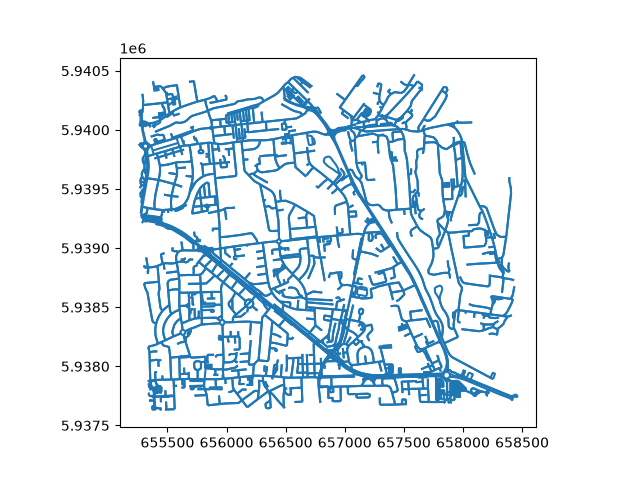

In [5]:
import osmnx as ox
from shapely.geometry import box

# From all segments, make a union and extract the bounds

segments_union = segments_gdf.unary_union
segments_union_bounds = segments_union.bounds if hasattr(segments_union, "bounds") else None
bbox_poly = box(*segments_union_bounds)

# Download only edges that are (at least partially) within bbox
# This will NOT download the full network, only roads partly or fully within the bbox
G = ox.graph_from_polygon(bbox_poly, network_type="all", retain_all=False)

# Convert to GeoDataFrame
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.set_crs("EPSG:4326", allow_override=True)

# Crop each road geometry to the bounding box (keep only cropped part inside bbox)
edges['geometry'] = edges['geometry'].intersection(bbox_poly)
edges = edges[~edges.is_empty]
utm_crs = edges.estimate_utm_crs()
edges = edges.to_crs(utm_crs)
edges.set_geometry('geometry', inplace=True)
edges.plot()

# Calculate the grid

In [6]:
#Prepares the gdf for grid creation. It translated to a (0,0) reference and create the Virtual Road
edges.nop.prepare_survey_gdf()

# Generate the grid based on the Virtual Road
road_grid = edges.nop.generate_grid()

# Create the network where the NOP is calculated, since we are creating the grid using OSM roads, this for the moment is not useful
net = edges.nop.create_network()

Center of the bounds: POINT (656858.23297 5939048.39436)
Processing angle:  0
Processing angle:  -10.0
Processing angle:  -20.0
Processing angle:  -30.0
Processing angle:  -40.0
Processing angle:  -50.0
Processing angle:  -60.0
Processing angle:  -70.0
Processing angle:  -80.0
Processing angle:  -90.0
Processing angle:  -100.0
Processing angle:  -110.0
Processing angle:  -120.0
Processing angle:  -130.0
Processing angle:  -140.0
Processing angle:  -150.0
Processing angle:  -160.0
Processing angle:  -170.0
Processing angle:  -180.0
Total boundaries: 15768
Boundaries with no NaN 'nop': 15541
Boundaries after length and spread filters: 14365
Boundaries after removing overlaps: 10794
Boundaries after removing close together cells: 9808
9808 splitters -> 9273 cells
Created network with 9273 nodes and 9768 edges.


# Plot the grid, the segments and the OSM Roads

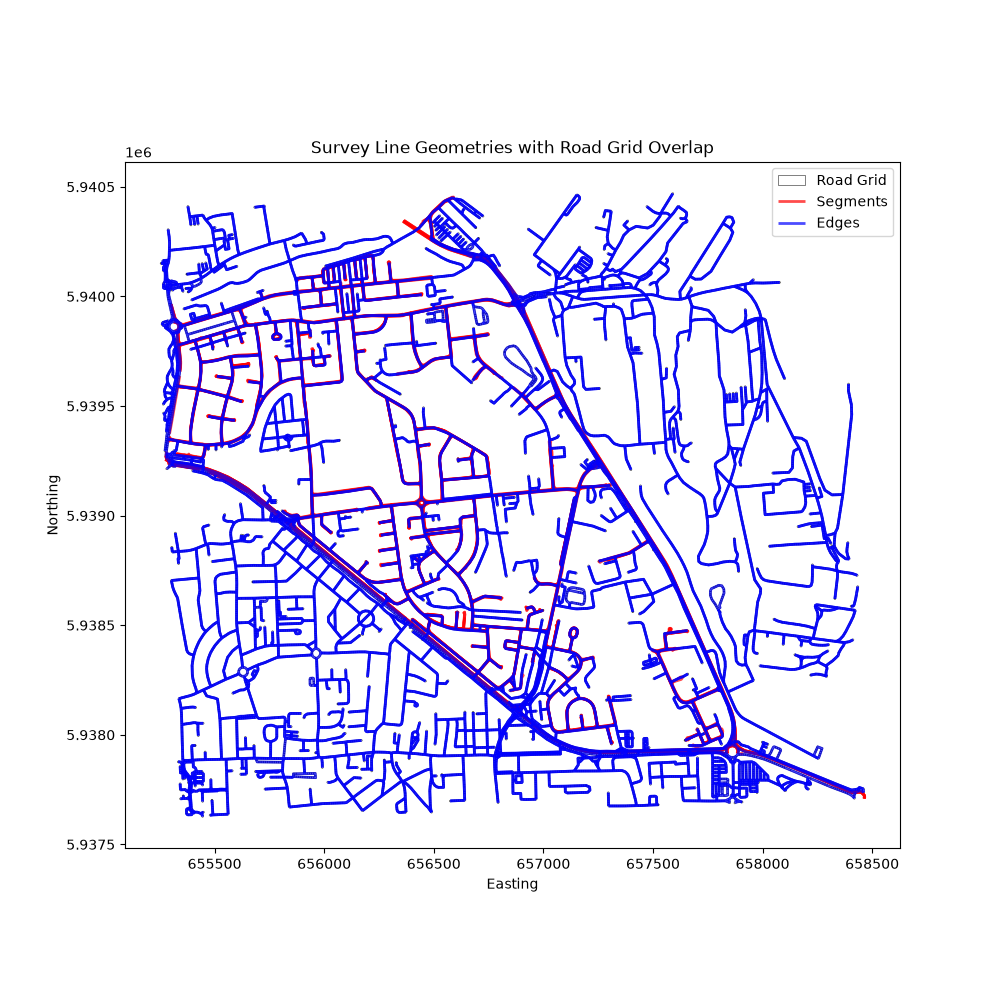

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the road grid
road_grid.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.7, label='Road Grid')

# Plot the segments on top
utm_crs = segments_gdf.estimate_utm_crs()
segments_gdf = segments_gdf.to_crs(utm_crs)
segments_gdf.plot(ax=ax, color='red', linewidth=2, alpha=0.7, label='Segments')
edges.plot(ax=ax, color='blue', linewidth=2, alpha=0.7, label='Edges')
ax.legend()
plt.title('Survey Line Geometries with Road Grid Overlap')
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.show()